# 01 - Análisis Exploratorio de Datos (EDA)

En este notebook se realiza el análisis exploratorio del dataset **San Francisco City Employee Salaries**.  
El objetivo es comprender la estructura de los datos, revisar la calidad de la información e identificar patrones iniciales que guíen el preprocesamiento y el modelado supervisado.

## 1. Objetivo del EDA y descripción del dataset

En esta sección se describe el dataset y las variables disponibles.  
El conjunto de datos contiene información de empleados de la ciudad de San Francisco, incluyendo nombre, cargo, diferentes componentes del salario y el año de registro.

Variables principales (originales):

- `EmployeeName`: nombre del empleado.
- `JobTitle`: cargo o puesto del empleado.
- `BasePay`: salario base.
- `OvertimePay`: pago por horas extra.
- `OtherPay`: otros pagos adicionales.
- `Benefits`: beneficios asociados al empleo.
- `TotalPay`: suma de pagos sin beneficios.
- `TotalPayBenefits`: suma de pagos incluyendo beneficios.
- `Year`: año del registro.

En este notebook se trabajará únicamente con el dataset original, sin aplicar todavía el preprocesamiento completo. El foco está en entender la distribución de las variables y detectar posibles problemas de calidad de datos (nulos, outliers, etc.).

In [29]:
# 2. Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("Librerías importadas.")

Librerías importadas.


## Carga del dataset

Se carga el archivo original desde la carpeta `data/raw/`, manteniendo una copia fiel del dataset antes de cualquier transformación. Esto permite conservar trazabilidad entre los datos originales y los datos procesados que se generarán después.

In [31]:
# 3. Carga del dataset

ruta_dataset = "../data/raw/dataset_original.csv"  # ajusta si lo tienes en otra carpeta

df = pd.read_csv(ruta_dataset, low_memory=False)

print(f"Dataset cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas\n")
df.head()

Dataset cargado: 148,654 filas, 13 columnas



,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.4300,567595.4300,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.2800,538909.2800,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.9100,335279.9100,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.6100,332343.6100,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.1900,326373.1900,2011,NaN,San Francisco,NaN


In [32]:
# 4. Información general del dataset

print("Tipos de datos:")
print(df.dtypes)
print("\nInformación completa:")
print(df.info())

Tipos de datos:
Id                    int64
EmployeeName            str
JobTitle                str
BasePay                 str
OvertimePay             str
OtherPay                str
Benefits                str
TotalPay            float64
TotalPayBenefits    float64
Year                  int64
Notes               float64
Agency                  str
Status                  str
dtype: object

Información completa:
<class 'pandas.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                148654 non-null  int64  
 1   EmployeeName      148654 non-null  str    
 2   JobTitle          148654 non-null  str    
 3   BasePay           148049 non-null  str    
 4   OvertimePay       148654 non-null  str    
 5   OtherPay          148654 non-null  str    
 6   Benefits          112495 non-null  str    
 7   TotalPay          148654 non-null  float64
 8 

In [33]:
# 5. Resumen estadístico de variables numéricas

df.describe()

,Id,TotalPay,TotalPayBenefits,Year,Notes
count,148654.0000,148654.0000,148654.0000,148654.0000,0.0000
mean,74327.5000,74768.3220,93692.5548,2012.5226,NaN
std,42912.8578,50517.0053,62793.5335,1.1175,NaN
min,1.0000,-618.1300,-618.1300,2011.0000,NaN
25%,37164.2500,36168.9950,44065.6500,2012.0000,NaN
50%,74327.5000,71426.6100,92404.0900,2013.0000,NaN
75%,111490.7500,105839.1350,132876.4500,2014.0000,NaN
max,148654.0000,567595.4300,567595.4300,2014.0000,NaN


In [34]:
df.describe(include="all")

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
count,148654.0000,148654,148654,148049,148654,148654,112495,148654.0000,148654.0000,148654.0000,0.0000,148654,38119
unique,NaN,110811,2159,109724,66162,84243,98647,NaN,NaN,NaN,NaN,1,2
top,NaN,Kevin Lee,Transit Operator,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,San Francisco,FT
freq,NaN,13,7036,872,57868,30068,1024,NaN,NaN,NaN,NaN,148654,22334
mean,74327.5000,NaN,NaN,NaN,NaN,NaN,NaN,74768.3220,93692.5548,2012.5226,NaN,NaN,NaN
std,42912.8578,NaN,NaN,NaN,NaN,NaN,NaN,50517.0053,62793.5335,1.1175,NaN,NaN,NaN
min,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,-618.1300,-618.1300,2011.0000,NaN,NaN,NaN
25%,37164.2500,NaN,NaN,NaN,NaN,NaN,NaN,36168.9950,44065.6500,2012.0000,NaN,NaN,NaN
50%,74327.5000,NaN,NaN,NaN,NaN,NaN,NaN,71426.6100,92404.0900,2013.0000,NaN,NaN,NaN
75%,111490.7500,NaN,NaN,NaN,NaN,NaN,NaN,105839.1350,132876.4500,2014.0000,NaN,NaN,NaN


In [35]:
# 6. Revisión de valores nulos y duplicados

print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nNúmero de filas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
Id                       0
EmployeeName             0
JobTitle                 0
BasePay                605
OvertimePay              0
OtherPay                 0
Benefits             36159
TotalPay                 0
TotalPayBenefits         0
Year                     0
Notes               148654
Agency                   0
Status              110535
dtype: int64

Número de filas duplicadas: 0


In [36]:
# 7. Clasificación de variables: numéricas vs categóricas

variables_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
variables_categoricas = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['Id', 'TotalPay', 'TotalPayBenefits', 'Year', 'Notes']

Variables categóricas:
['EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay', 'Benefits', 'Agency', 'Status']


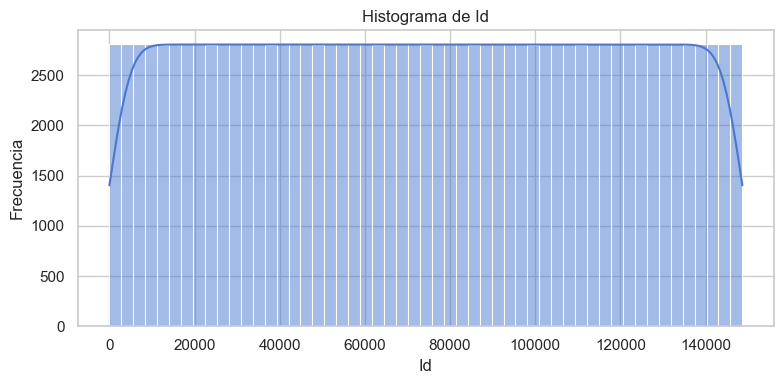

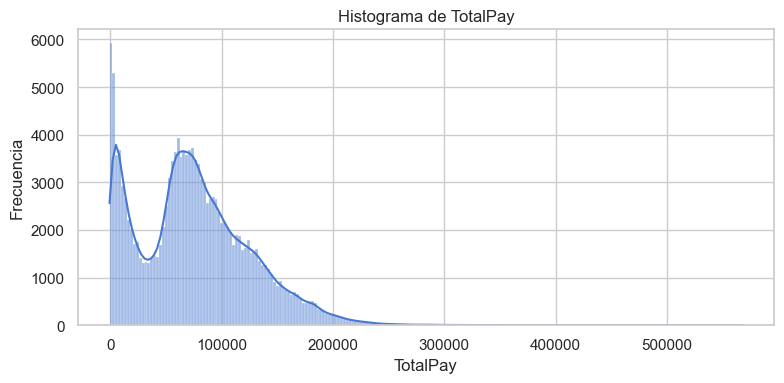

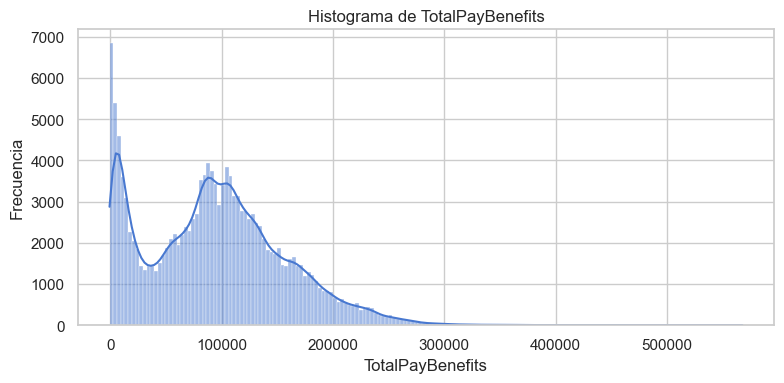

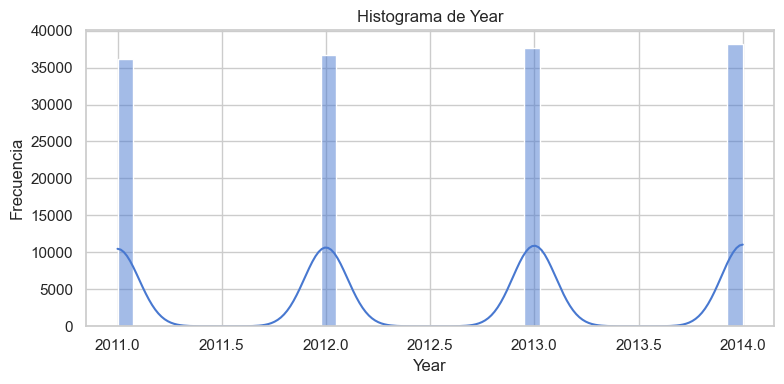

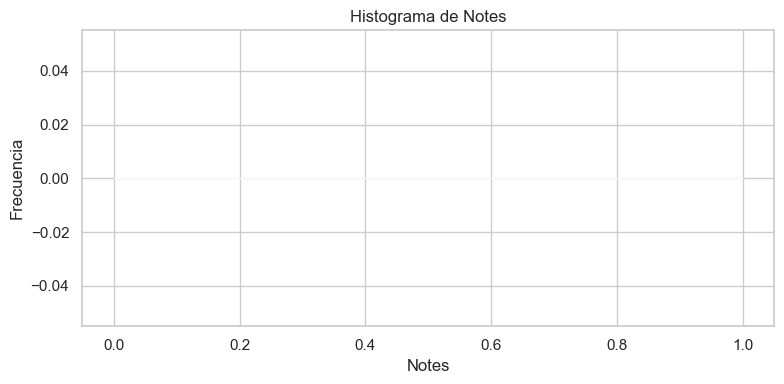

In [37]:
# 8. Análisis univariado: histogramas de variables numéricas

for col in variables_numericas:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

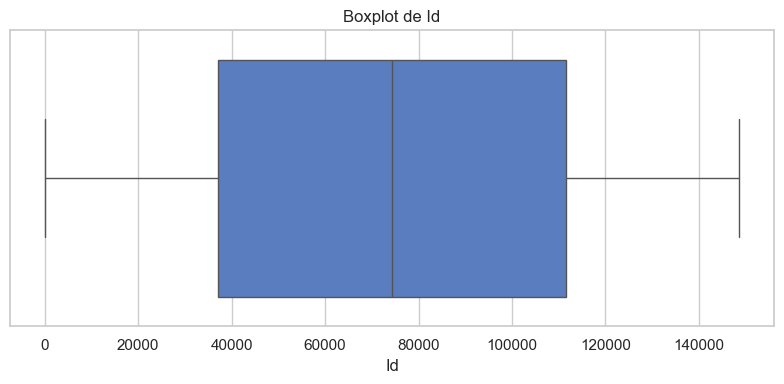

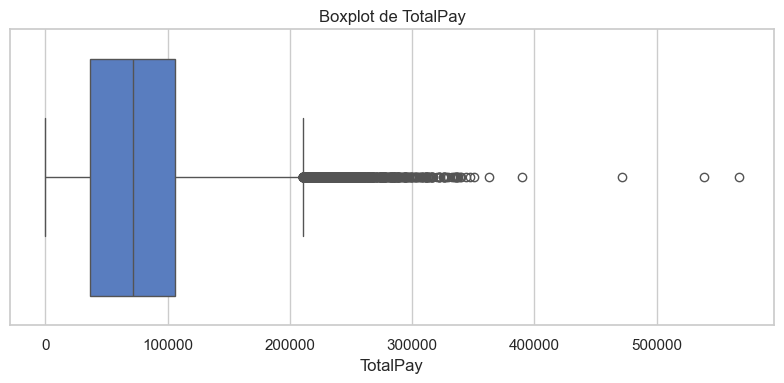

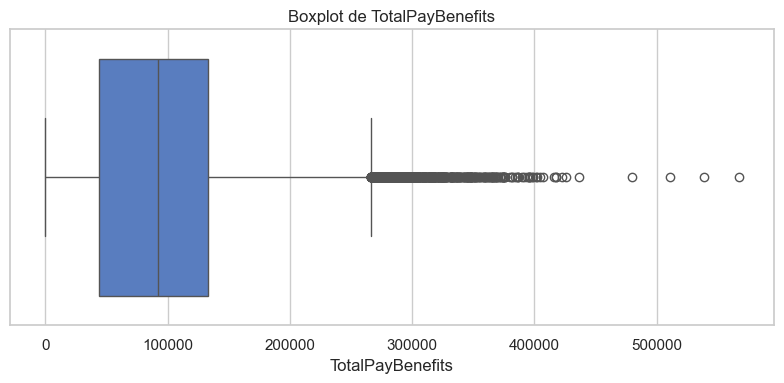

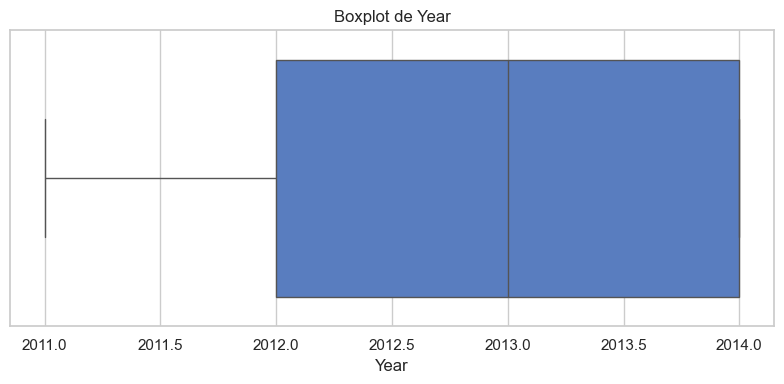

Columna Notes: sin datos numéricos válidos, se omite.


In [38]:
# 9. Análisis univariado: boxplots de variables numéricas

for col in variables_numericas:
    datos = pd.to_numeric(df[col], errors="coerce").dropna()
    
    if datos.empty:
        print(f"Columna {col}: sin datos numéricos válidos, se omite.")
        continue
    
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=datos)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Interpretación de los boxplots de variables numéricas

Con base en los boxplots visibles para las columnas `Id`, `TotalPay`, `TotalPayBenefits` y `Year`, se puede comentar lo siguiente:

- **`Id`**: muestra una distribución esencialmente uniforme que crece a medida que aumentan los registros. Esto es esperable porque `Id` funciona como un identificador único de cada fila, no como una medida económica. El boxplot no aporta información analítica relevante sobre el comportamiento salarial, y por ello esta columna se considerará solo como identificador y no como predictor.
- **`TotalPay`**: presenta una distribución claramente asimétrica, con muchos valores concentrados en rangos bajos y una cola larga hacia valores altos. Los puntos alejados del bigote superior corresponden a empleados con salarios totales muy superiores a la media, es decir, **outliers salariales**. Estos casos pueden ser directivos, cargos altamente especializados o registros anómalos, y motivan la necesidad de aplicar técnicas de tratamiento de outliers (por ejemplo, winsorización) en el preprocesamiento.
- **`TotalPayBenefits`**: el patrón es similar al de `TotalPay`, pero incluyendo el componente de beneficios. La concentración de la mayoría de los datos en un rango relativamente acotado y la presencia de valores extremos refuerzan la idea de que el sistema salarial tiene una base común para la mayoría de empleados, con un grupo reducido con 
- **`Year`**: el boxplot de `Year` muestra que solo hay algunos valores discretos correspondientes a años específicos del registro (por ejemplo 2011, 2012, 2013, etc.), por lo que no tiene la misma interpretación que una variable continua. En este contexto, `Year` sirve más como referencia temporal que como variable numérica tradicional; su uso como predictor dependerá de si se observa alguna diferencia sistemática en los salarios entre años en análisis posteriores.

En resumen, los boxplots evidencian que las variables de salario total (`TotalPay` y `TotalPayBenefits`) presentan valores extremos importantes, lo que justifica aplicar técnicas de tratamiento de outliers y un preprocesamiento adecuado antes de ajustar modelos supervisados.

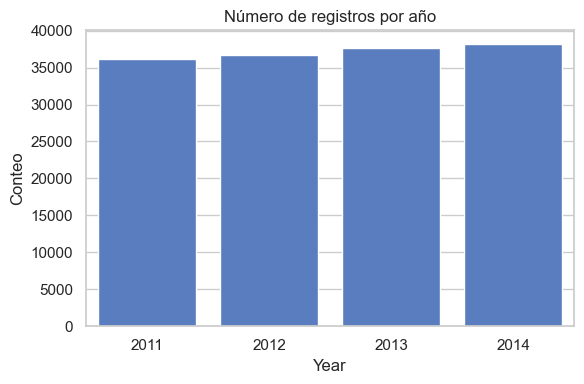

In [39]:
# 10. Distribución de registros por año

if "Year" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x="Year")
    plt.title("Número de registros por año")
    plt.xlabel("Year")
    plt.ylabel("Conteo")
    plt.tight_layout()
    plt.show()

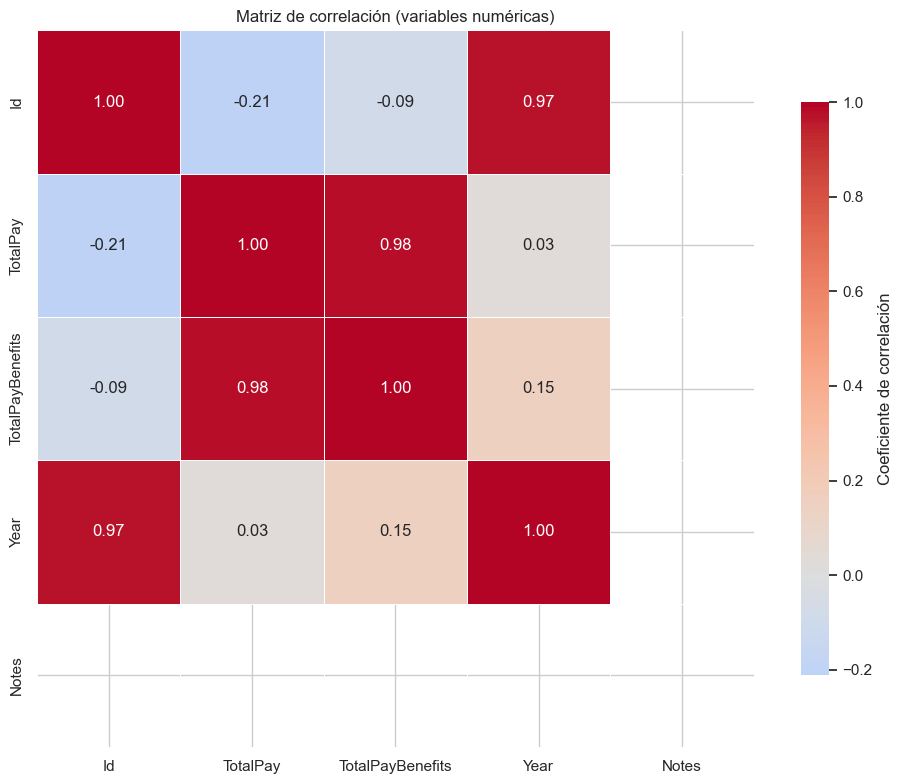

In [41]:
# 11. Matriz de correlación entre variables numéricas (con valores)

plt.figure(figsize=(10, 8))

# Calculamos la matriz de correlación
corr = df[variables_numericas].corr()

sns.heatmap(
    corr,
    annot=True,          # Mostrar los valores numéricos
    fmt=".2f",           # Formato de los números (2 decimales)
    cmap="coolwarm",
    center=0,
    square=True,         # Cuadrados proporcionales
    linewidths=0.5,      # Líneas entre celdas
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de correlación"}
)

plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

### Interpretación de la matriz de correlación

En la matriz de correlación se observa lo siguiente:

- Las variables **`TotalPay`** y **`TotalPayBenefits`** presentan una correlación muy alta y positiva (cercana a 1.00), lo cual es esperable porque `TotalPayBenefits` incluye a `TotalPay` más el componente de beneficios.
- **`BasePay`** muestra una correlación positiva fuerte con **`TotalPay`** y **`TotalPayBenefits`**, lo que indica que el salario base es uno de los factores principales que explican el salario total del empleado.
- Las variables de componentes adicionales, como **`OvertimePay`** y **`OtherPay`**, tienden a tener correlaciones moderadas con `TotalPay`, reflejando que contribuyen al monto total pero con menor peso que `BasePay`.
- La variable **`Year`** en general presenta correlaciones bajas con la mayoría de variables de salario, lo que sugiere que no hay una tendencia lineal fuerte entre el año del registro y los valores de pago dentro de este dataset.

Estas relaciones ayudan a identificar qué variables numéricas están más asociadas con el salario total y servirán posteriormente para seleccionar y justificar los **features** usados en los modelos supervisados.

## 12. Hallazgos del EDA

A partir del análisis exploratorio se observa lo siguiente:

- Existen variables numéricas relacionadas con diferentes componentes del salario (`BasePay`, `OvertimePay`, `OtherPay`, `Benefits`, `TotalPay`, `TotalPayBenefits`). Estas variables muestran distribuciones con posibles outliers y colas largas, especialmente en pagos y beneficios.
- El dataset contiene información de varios años (`Year`), lo que permite analizar el comportamiento de los salarios a lo largo del tiempo si fuera necesario.
- Algunas variables categóricas como `EmployeeName` y `JobTitle` tienen una alta cardinalidad. `JobTitle` será relevante para el modelado posterior, mientras que `EmployeeName` se utilizará principalmente como identificador y no como predictor.
- Se observan valores nulos en algunas columnas numéricas (por ejemplo en `BasePay` o `Benefits`), que requerirán un tratamiento específico en la etapa de preprocesamiento.
- La matriz de correlación muestra relaciones fuertes entre `TotalPay`, `TotalPayBenefits` y los diferentes componentes del salario, lo cual es consistente con la definición de estas variables.

Estos hallazgos motivan las decisiones de preprocesamiento que se implementarán en el notebook **02_preprocesamiento.ipynb**, donde se abordarán la imputación de nulos, el tratamiento de outliers y la creación de la variable objetivo `TieneOvertime` para el problema de clasificación supervisada.